### PH464/564: Scientific Computing II
___

# Homework 5
### Due: Mon, Nov 3rd at 11:59pm Pacific
---

# Modeling w/ NumPyro

1. Use `NumPyro` to define a model containing a single random variable that follows a [Gamma](https://en.wikipedia.org/wiki/Gamma_distribution) [distribution](https://num.pyro.ai/en/stable/distributions.html#gamma) with shape parameters $\alpha=5$, $\beta=0.1$.  First draw samples directly from the distribution and plot the histogram and/or KDE.

2. Using the samples you've drawn, compute the mean and variance of the random variable. Modify the shape parameters individually to see how each of them affect the mean and variance of the distribution.

3. The Gamma distribution doesn't have support for negative values, making it a useful prior distribution for parameters that must be positive. Use `NumPyro` to conduct an MCMC sampling of our linear regression model with outliers from class, but replace the half-normal priors for standard deviation parameters with sensible gamma distributions (i.e., not dramatically different in scale from the half-normal distributions previously used). Does the change in prior distribution meaningfully change the posterior distributions?

## 564 students
Repeat the Gaia linear regression analysis from the 564 portion of last week's homework, this time using `NumPyro`.

1. How do your results compare?
2. How about the efficiency of sampling?
3. Use the posterior predictive framework in `NumPyro` to simulate a new Gaia catalog from your model and posterior estimate.  How does it compare to the observed data?  How might we improve our model?

## Part 1, Problem 1

In [1]:
from numpy import genfromtxt

import jax
from jax import random
import jax.numpy as jnp

import numpyro
import numpyro.distributions as dist
from numpyro import infer
numpyro.set_host_device_count(1) # let's use 2 cores!

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import pandas as pd

In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
font = {'size' : 12}
plt.rc('font', **font)

In [3]:
rng_key = random.PRNGKey(0)

In [4]:
α = 5
β = 0.1

samples = dist.Gamma(concentration=α, rate=β).sample(rng_key, (10000,))

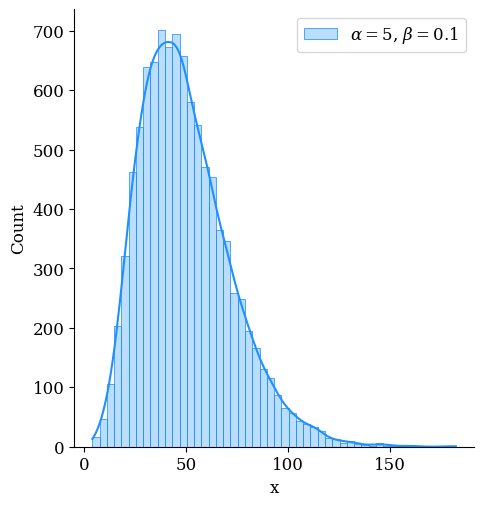

In [5]:
sns.displot(samples, color='dodgerblue', alpha=0.3, edgecolor='dodgerblue', bins=50, kde=True, label=fr'$\alpha={α}$, $\beta={β}$')
plt.xlabel('x')
plt.legend()

plt.show()

In [6]:
print('mean of Gamma distribution samples: %.2f' % jnp.mean(samples))
print('variance of Gamma distribution samples: %.2f' % jnp.var(samples))

mean of Gamma distribution samples: 49.90
variance of Gamma distribution samples: 490.41


## Part 1, Problem 2

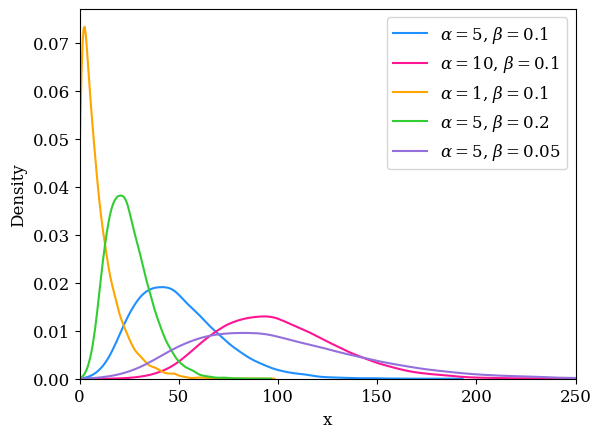

mean and variance of Gamma distribution samples with α = 5, β = 0.1: 49.90 490.4144
mean and variance of Gamma distribution samples with α = 10, β = 0.1: 99.90 982.5078
mean and variance of Gamma distribution samples with α = 1, β = 0.1: 9.89 96.405594
mean and variance of Gamma distribution samples with α = 5, β = 0.2: 24.95 122.6036
mean and variance of Gamma distribution samples with α = 5, β = 0.05: 99.79 1961.6576


In [17]:
α1 = 10
β1 = 0.1

α2 = 1
β2 = 0.1

α3 = 5
β3 = 0.2

α4 = 5
β4 = 0.05

samples1 = dist.Gamma(concentration=α1, rate=β1).sample(rng_key, (10000,))
samples2 = dist.Gamma(concentration=α2, rate=β2).sample(rng_key, (10000,))
samples3 = dist.Gamma(concentration=α3, rate=β3).sample(rng_key, (10000,))
samples4 = dist.Gamma(concentration=α4, rate=β4).sample(rng_key, (10000,))

sns.kdeplot(samples, color='dodgerblue', label=fr'$\alpha={α}$, $\beta={β}$')
sns.kdeplot(samples1, color='deeppink', label=fr'$\alpha={α1}$, $\beta={β1}$')
sns.kdeplot(samples2, color='orange', label=fr'$\alpha={α2}$, $\beta={β2}$')
sns.kdeplot(samples3, color='limegreen', label=fr'$\alpha={α3}$, $\beta={β3}$')
sns.kdeplot(samples4, color='mediumpurple', label=fr'$\alpha={α4}$, $\beta={β4}$')

plt.xlabel('x')
plt.xlim(0,250)
plt.legend()
plt.show()

print('mean and variance of Gamma distribution samples with α = 5, β = 0.1: %.2f' % jnp.mean(samples), jnp.var(samples))
print('mean and variance of Gamma distribution samples with α = 10, β = 0.1: %.2f' % jnp.mean(samples1), jnp.var(samples1))
print('mean and variance of Gamma distribution samples with α = 1, β = 0.1: %.2f' % jnp.mean(samples2), jnp.var(samples2))
print('mean and variance of Gamma distribution samples with α = 5, β = 0.2: %.2f' % jnp.mean(samples3), jnp.var(samples3))
print('mean and variance of Gamma distribution samples with α = 5, β = 0.05: %.2f' % jnp.mean(samples4), jnp.var(samples4))

## Part 1, Problem 3

In [18]:
data = genfromtxt('./data/data_yerr.dat', names=True, comments='#', delimiter='&')
data

array([( 1., 201., 592., 61.), ( 2., 244., 401., 25.),
       ( 3.,  47., 583., 38.), ( 4., 287., 402., 15.),
       ( 5., 203., 495., 21.), ( 6.,  58., 173., 15.),
       ( 7., 210., 479., 27.), ( 8., 202., 504., 14.),
       ( 9., 198., 510., 30.), (10., 158., 416., 16.),
       (11., 165., 393., 14.), (12., 201., 442., 25.),
       (13., 157., 317., 52.), (14., 131., 311., 16.),
       (15., 166., 400., 34.), (16., 160., 337., 31.),
       (17., 186., 423., 42.), (18., 125., 334., 26.),
       (19., 218., 533., 16.), (20., 146., 344., 22.)],
      dtype=[('index', '<f8'), ('x', '<f8'), ('y', '<f8'), ('sigm_y', '<f8')])

In [19]:
def plot_data():
    plt.errorbar(data['x'], data['y'], yerr=data['sigm_y'], fmt=",k", ms=0, capsize=0, lw=1)
    plt.scatter(data['x'], data['y'], marker="o", s=5, c="k", label="data")
    plt.xlabel('x')
    plt.ylabel('y')

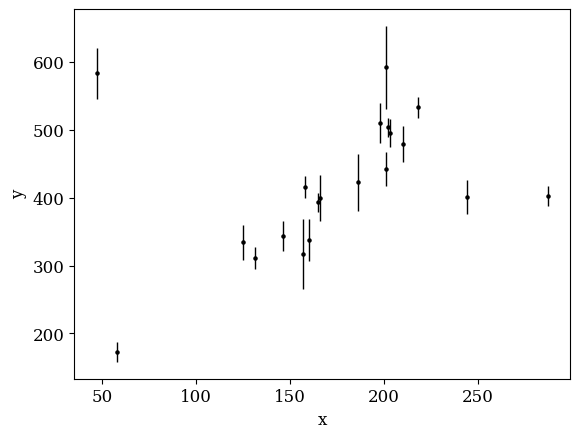

In [20]:
plot_data()
plt.show()

In [23]:
def linear_model_w_outliers(x=None, y=None, σ_y=None):
    # First let's construct our foreground (i.e., linear) model
    m = numpyro.sample('m', dist.Uniform(0, 5))
    b = numpyro.sample('b', dist.Uniform(0, 500))
    μ_fg = m * x + b
    dist_fg = dist.Normal(μ_fg, σ_y)

    # Now lets define a model for the background (i.e., outliers)
    μ_bg = numpyro.sample('μ_bg', dist.Normal(loc=400, scale=500))
    σ_bg = numpyro.sample('σ_bg', dist.Gamma(concentration=2, rate=0.006))
    dist_bg = dist.Normal(μ_bg, jnp.sqrt(σ_bg**2 + σ_y**2))

    # We're going to assign each observation probabilistically to fg or bg using Categorical parameters
    P_fg = numpyro.sample('P_fg', dist.Uniform(0, 1)) # Prob an observation will be in the foreground

    # Define the foreground/background parameters, with equal probability between categories
    mixing_dist = dist.Categorical(probs=jnp.array([P_fg, 1 - P_fg]))
    mixture = dist.MixtureGeneral(mixing_dist, [dist_fg, dist_bg])

    # Likelihood
    with numpyro.plate("data", len(x)):
        y_ = numpyro.sample("obs", mixture, obs=y)

        # Until here, where we can track the membership probability of each sample
        log_probs = mixture.component_log_probs(y_)
        numpyro.deterministic(
            "log_p_fg", log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
        )

In [24]:
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(3)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(linear_model_w_outliers)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=data['x'],
         y=data['y'],
         σ_y=data['sigm_y'])
mcmc.print_summary()

/tmp/ipykernel_472/3101557400.py:7: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = infer.MCMC(
sample: 100%|██████████| 6000/6000 [00:09<00:00, 602.94it/s, 15 steps of size 1.77e-01. acc. prob=0.88]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      P_fg      0.72      0.12      0.74      0.54      0.92   4904.21      1.00
         b     34.45     17.51     33.85      4.97     61.71   3301.75      1.00
         m      2.24      0.11      2.25      2.08      2.43   3221.21      1.00
      μ_bg    446.88     86.86    446.28    318.45    574.58   2449.13      1.00
      σ_bg    144.81     91.59    119.04     40.40    260.76   3038.63      1.00

Number of divergences: 0


/home/.hub_local/python_libs/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


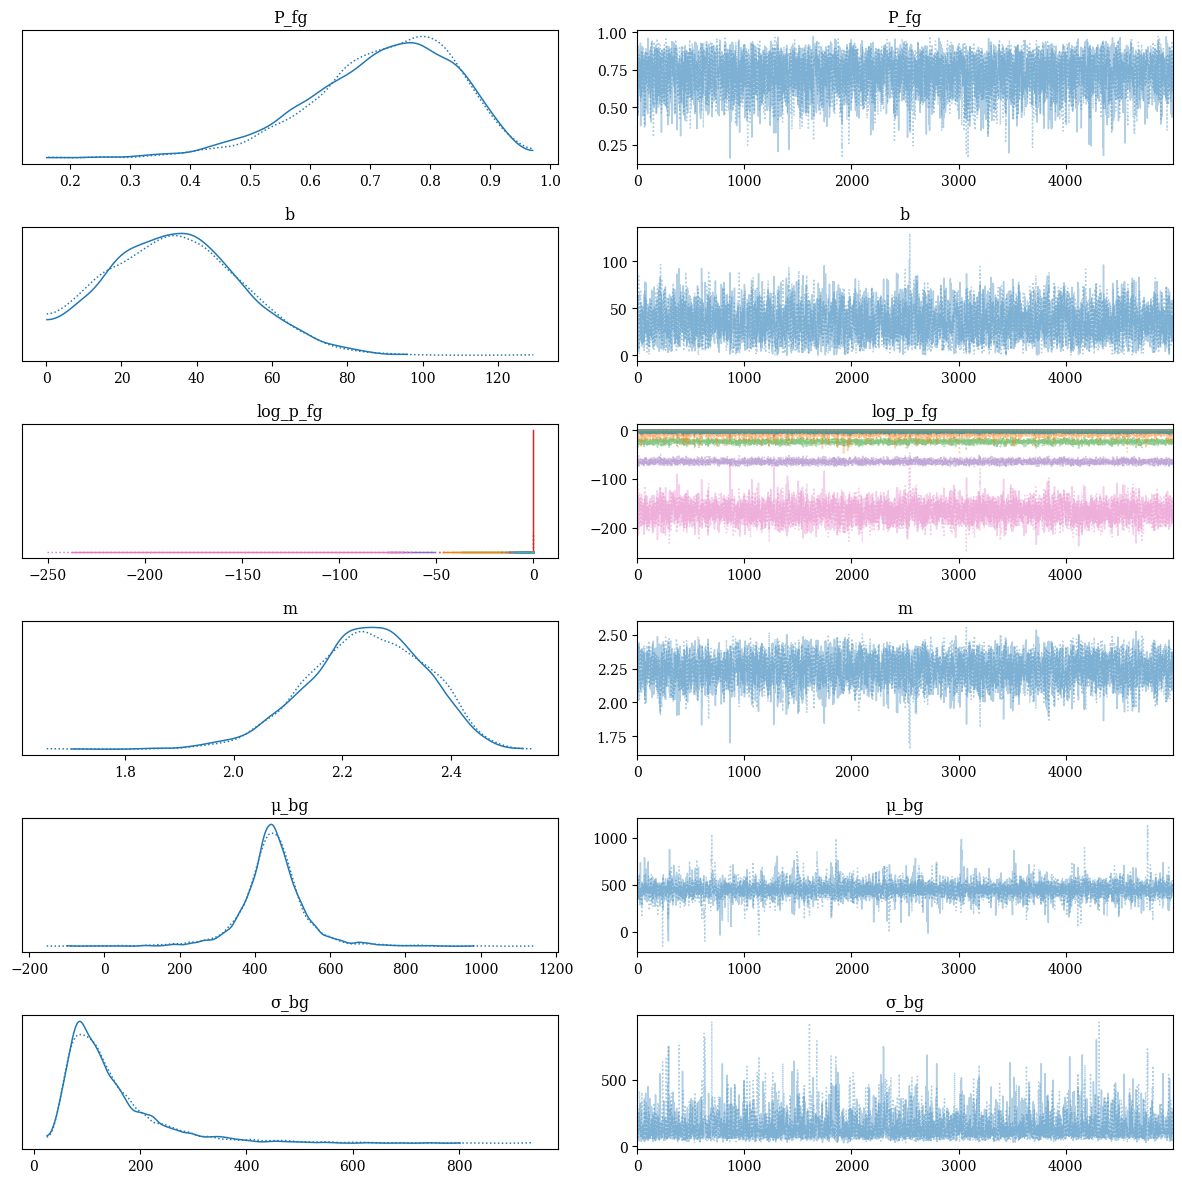

In [25]:
az.plot_trace(mcmc);
plt.tight_layout()
plt.show()

In [26]:
samples = mcmc.get_samples()
samples

{'P_fg': Array([0.7409456 , 0.5749398 , 0.82966405, ..., 0.59964925, 0.65160835,
        0.81132424], dtype=float32),
 'b': Array([53.201893, 48.288036, 20.163288, ..., 40.600784, 21.28588 ,
        11.437555], dtype=float32),
 'log_p_fg': Array([[[-6.1234474e-02, -2.8235092e+00],
         [-2.3261202e+01,  0.0000000e+00],
         [-5.7748943e+01,  0.0000000e+00],
         ...,
         [-8.1966877e-02, -2.5421467e+00],
         [-4.9242973e-03, -5.3160343e+00],
         [-1.3082170e-01, -2.0986171e+00]],
 
        [[-9.4812965e-01, -4.9014902e-01],
         [-2.0982630e+01,  0.0000000e+00],
         [-6.3591934e+01,  0.0000000e+00],
         ...,
         [-5.7575703e-02, -2.8833055e+00],
         [-1.9515419e-01, -1.7299562e+00],
         [-6.0642719e-02, -2.8329220e+00]],
 
        [[-2.7907324e-01, -1.4125743e+00],
         [-2.1021091e+01,  0.0000000e+00],
         [-6.8516411e+01,  0.0000000e+00],
         ...,
         [-2.0064831e-02, -3.9187908e+00],
         [-2.2656918e-02,

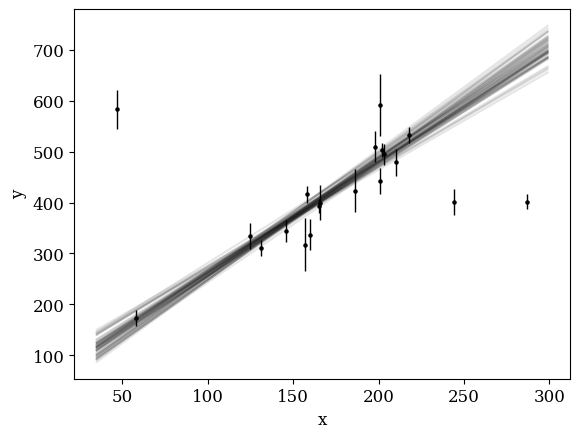

In [27]:
plot_data()

xlow, xhigh = plt.xlim()
x = jnp.linspace(xlow, xhigh, 100)

for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['m'][i] * x + samples['b'][i]
    plt.plot(x, mu, color='k', alpha=0.1);
    
plt.show()

In [28]:
p_fg = jnp.mean(jnp.exp(samples["log_p_fg"][..., 0]), axis=0)
σ_p_fg = jnp.std(jnp.exp(samples["log_p_fg"][..., 0]), axis=0)

p_fg.shape

(20,)

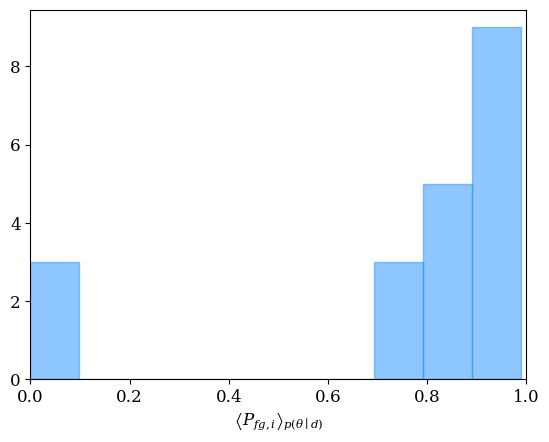

In [29]:
plt.hist(p_fg, color='dodgerblue', alpha=0.5, edgecolor='dodgerblue')
plt.xlabel(r"$\left<P_{fg,i}\right>_{p(\theta\mid d)}$")

plt.xlim(0, 1);

plt.show()

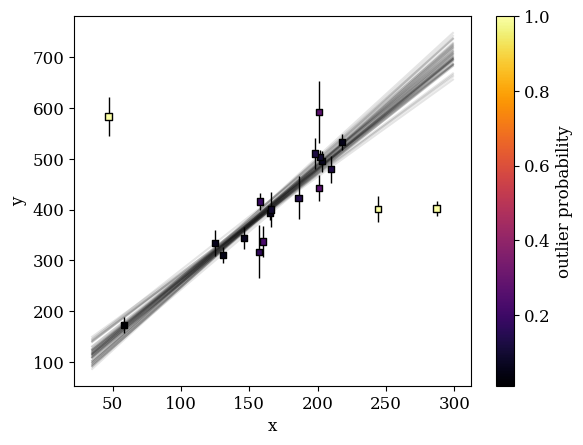

In [30]:
plot_data()

for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['m'][i] * x + samples['b'][i]
    plt.plot(x, mu, color='k', alpha=0.1);

plt.scatter(data['x'], data['y'], marker="s", s=20, c=1 - p_fg, zorder=99, edgecolor="k", cmap="inferno")
plt.colorbar(label="outlier probability");

plt.show()

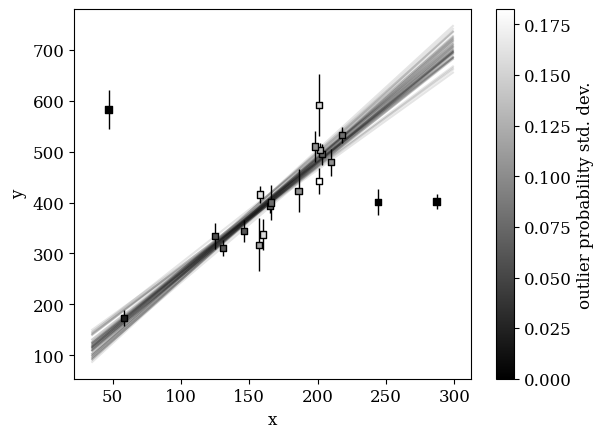

In [31]:
plot_data()

for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['m'][i] * x + samples['b'][i]
    plt.plot(x, mu, color='k', alpha=0.1);

plt.scatter(data['x'], data['y'], marker="s", s=20, c=σ_p_fg, zorder=99, edgecolor="k", cmap="gray")
plt.colorbar(label="outlier probability std. dev.");

plt.show()

## Part 2

In [20]:
df = pd.read_csv('../../hub_data_share/gaiadr3_solar_neighborhood.csv')
df

,mg,bp_rp,parallax
0,10.390250,2.731872,10.000008
1,8.608481,2.025819,10.000029
2,4.267759,0.880858,10.000032
3,10.506658,2.649735,10.000066
4,12.077941,2.940875,10.000111
...,...,...,...
227624,11.758283,2.834036,336.026602
227625,9.521769,2.215609,392.752945
227626,14.129570,4.184836,415.179416
227627,11.883816,2.833697,546.975940


In [21]:
nearby_sel = df.parallax > 40.
nearby_df = df[nearby_sel]

In [22]:
wd_color = (-0.4, 1.8)
wd_mg = (10, 16.5)

wd_sel = ((nearby_df.bp_rp > wd_color[0]) & (nearby_df.bp_rp < wd_color[1]) &
    (nearby_df.mg > wd_mg[0]) & (nearby_df.mg < wd_mg[1]))

main_df = nearby_df[~wd_sel]

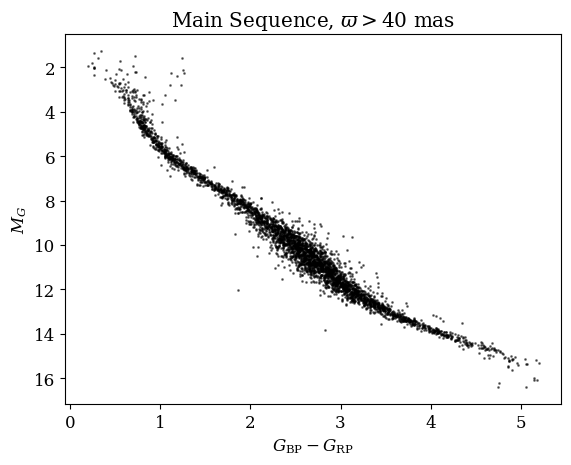

In [23]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.gca().invert_yaxis()
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

plt.show()

In [24]:
def linear_model(x=None, y=None, σ_y=None):
    # priors
    m = numpyro.sample('m', dist.Uniform(0, 5))
    b = numpyro.sample('b', dist.Uniform(0, 500))
    σ_y = numpyro.sample('σ_y', dist.HalfNormal(5))

    # define the mean of the normal distribution
    μ = m * x + b

    # Likelihood
    with numpyro.plate("data", len(x)):
        numpyro.sample("y", dist.Normal(μ, σ_y), obs=y)

In [33]:
x = jnp.array(main_df['bp_rp'])
y = jnp.array(main_df['mg'])

rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(linear_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

/tmp/ipykernel_2902/2014247536.py:9: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = infer.MCMC(
sample: 100%|██████████| 6000/6000 [00:13<00:00, 451.89it/s, 15 steps of size 2.49e-01. acc. prob=0.94]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      2.58      0.03      2.58      2.54      2.63   3813.58      1.00
         m      2.94      0.01      2.94      2.92      2.95   3785.13      1.00
       σ_y      0.57      0.01      0.57      0.56      0.58   4842.09      1.00

Number of divergences: 0


In [34]:
samples = mcmc.get_samples()
samples

{'b': Array([2.5783582, 2.609351 , 2.6207159, ..., 2.5744715, 2.5877566,
        2.5648985], dtype=float32),
 'm': Array([2.9403358, 2.9255238, 2.9236624, ..., 2.9309332, 2.9351041,
        2.942926 ], dtype=float32),
 'σ_y': Array([0.5802017 , 0.5722329 , 0.57335794, ..., 0.5673038 , 0.5695531 ,
        0.5684729 ], dtype=float32)}

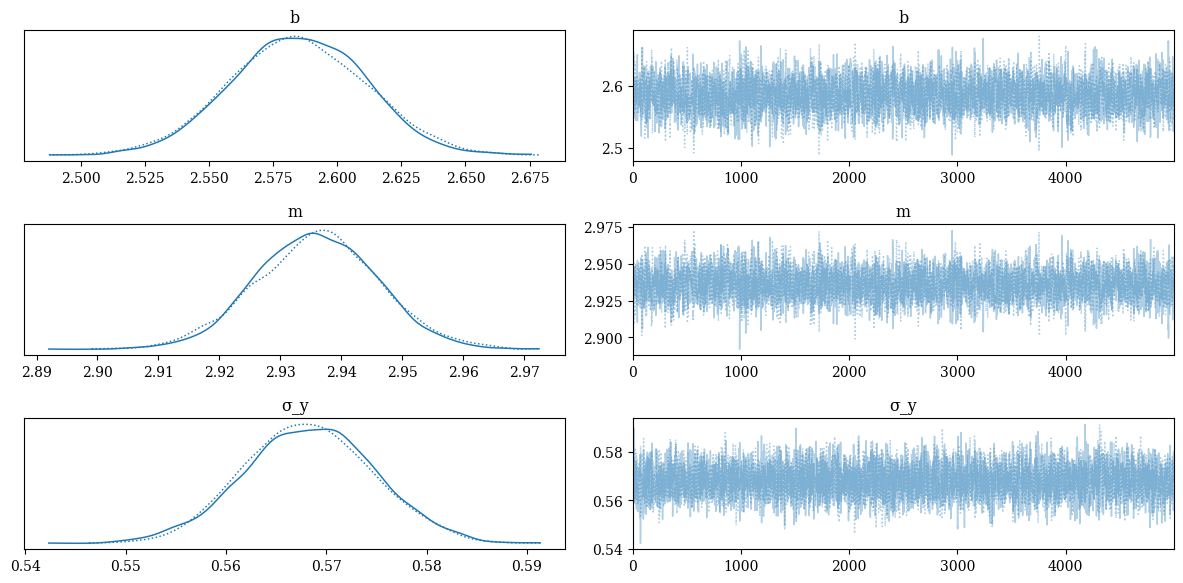

In [35]:
az.plot_trace(mcmc);
plt.tight_layout()
plt.show()

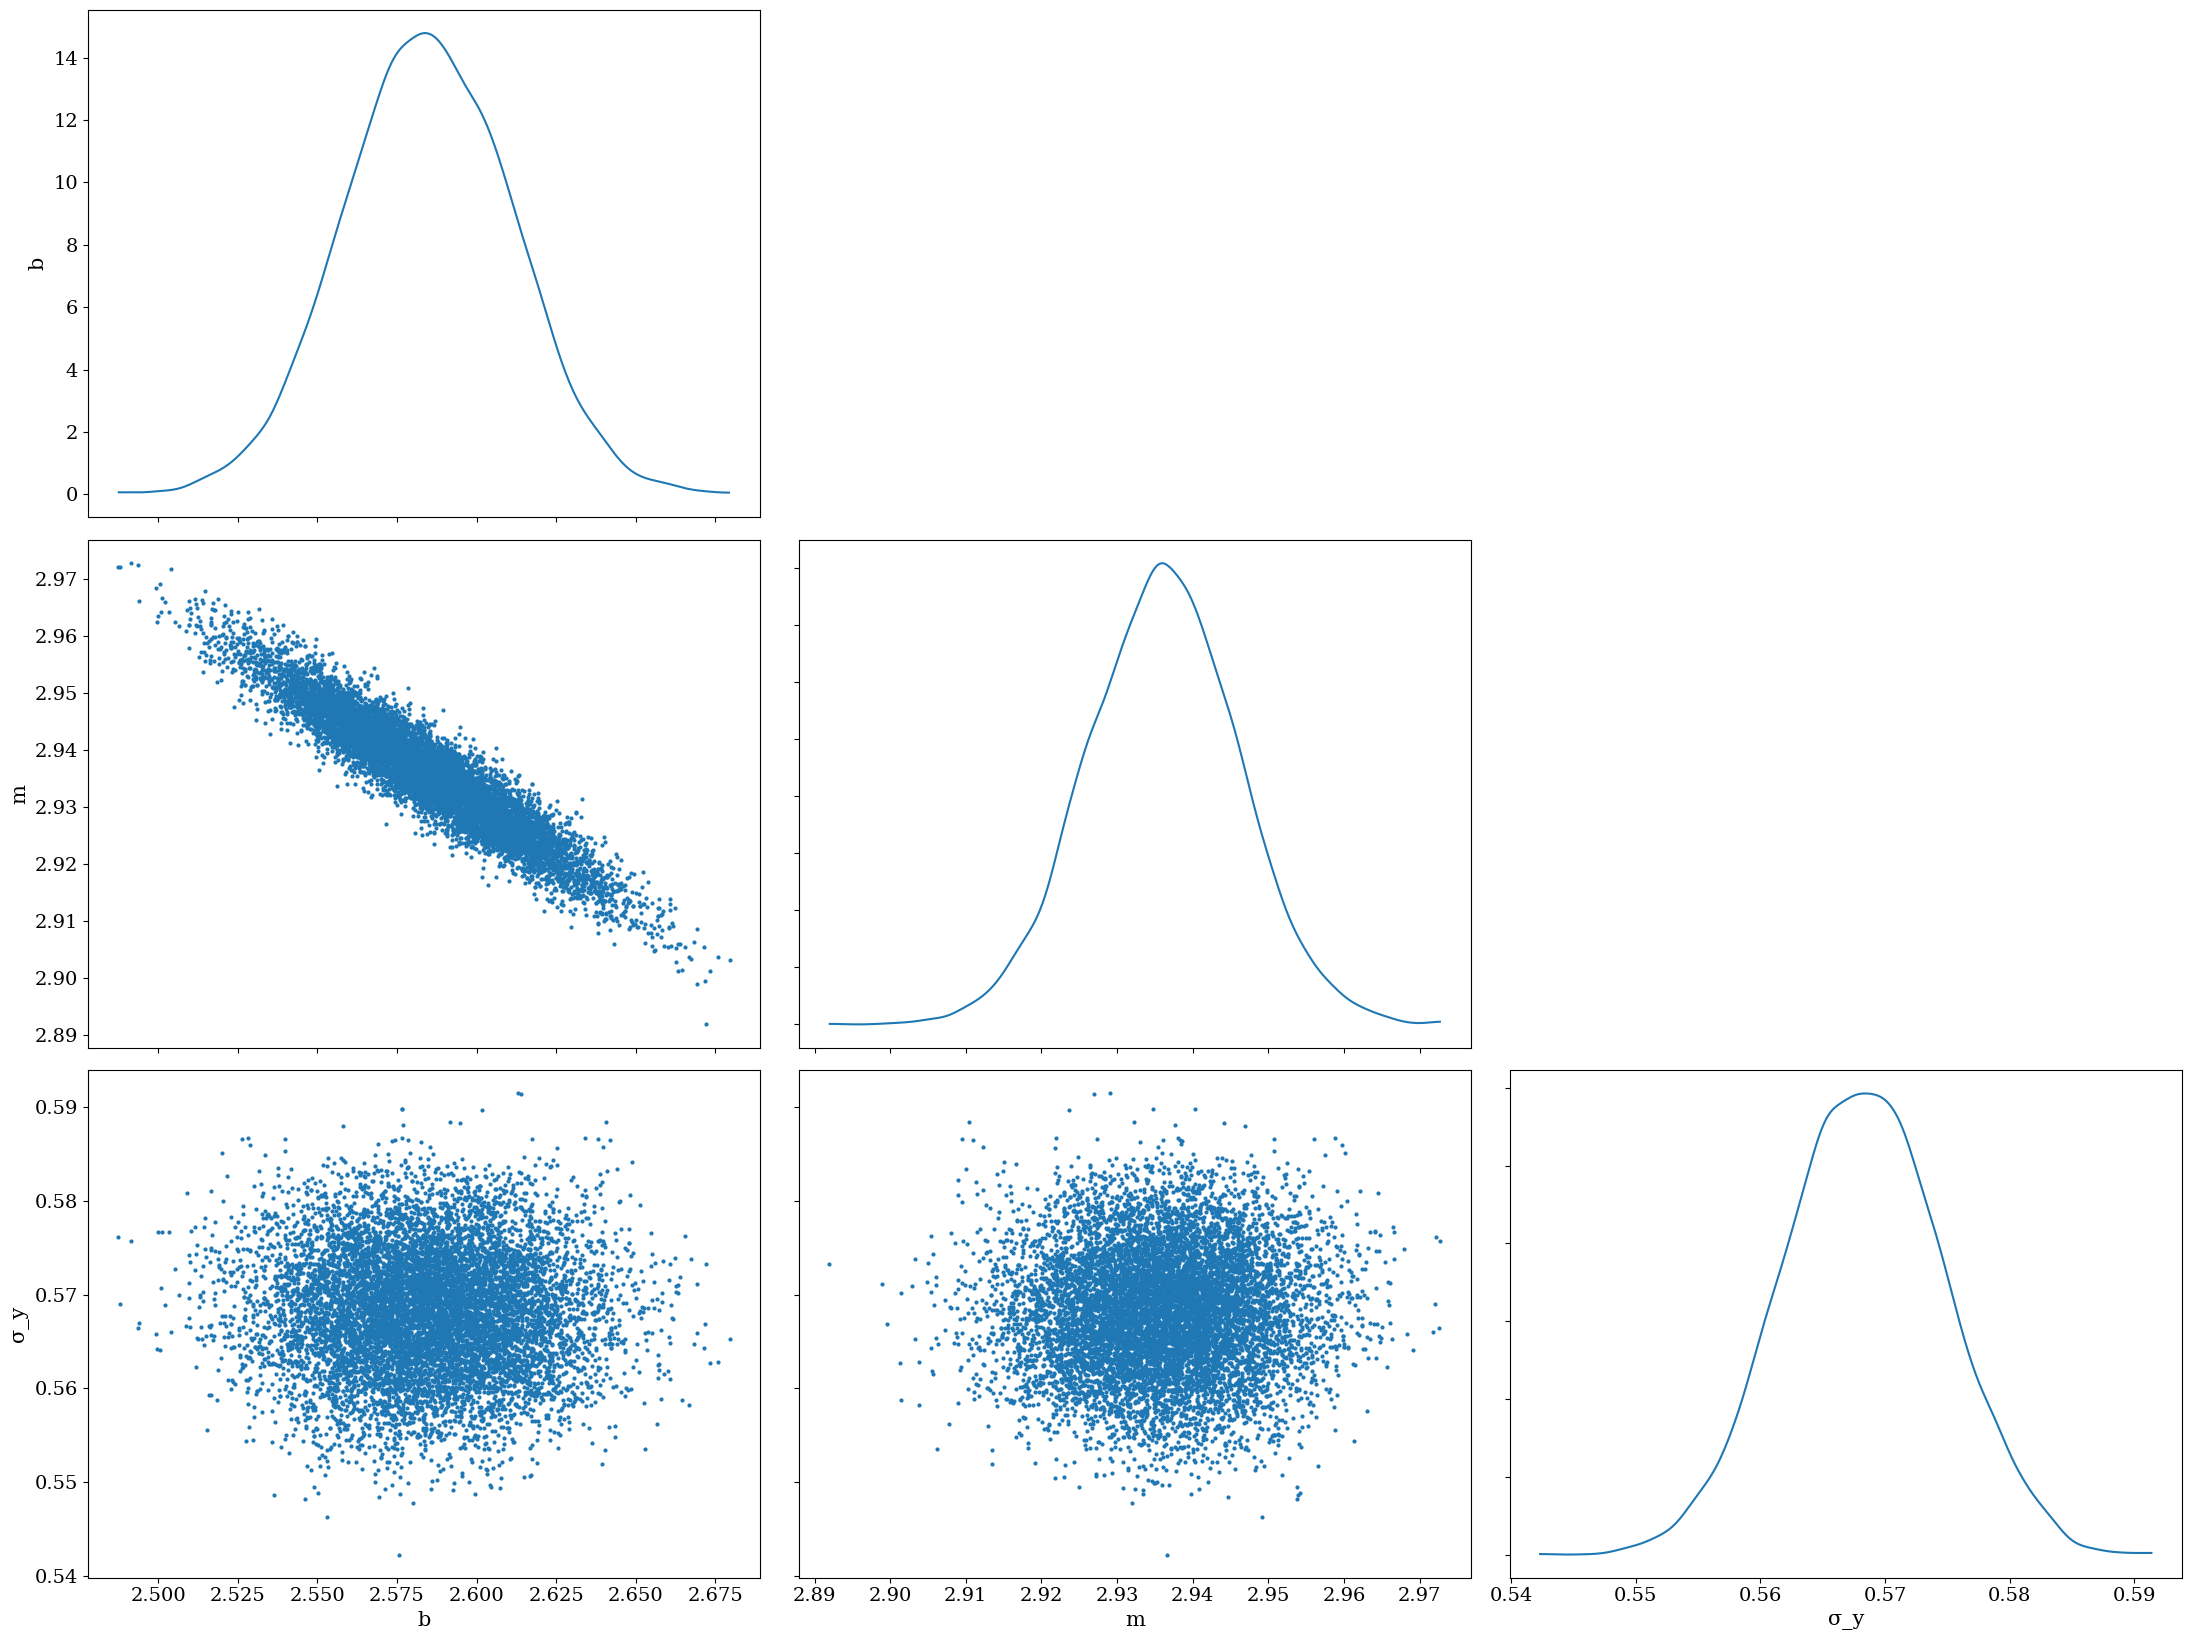

In [36]:
az.plot_pair(mcmc,marginals=True)
plt.tight_layout()
plt.show()

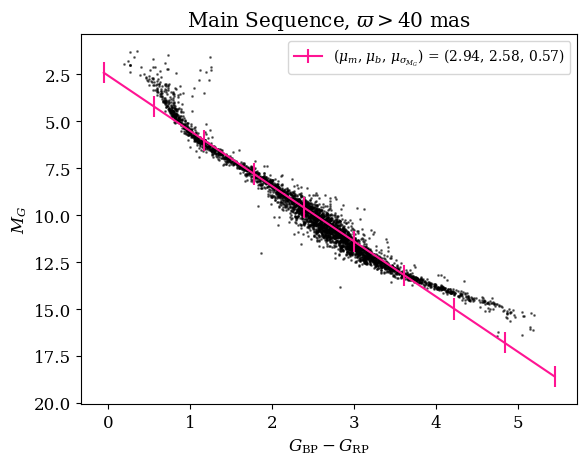

In [37]:
mean_m = jnp.mean(samples['m']).item()
mean_b = jnp.mean(samples['b']).item()
mean_sigmg = jnp.mean(samples['σ_y']).item()

plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
x = jnp.linspace(xlow, xhigh, 10)
mu = mean_m * x + mean_b

plt.errorbar(x, mu, yerr=mean_sigmg, color='deeppink',  
             label=fr'($\mu_m$, $\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$, ${round(mean_sigmg,2)}$)')
    
plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

In [38]:
x = jnp.array(main_df['bp_rp'])
y = jnp.array(main_df['mg'])

post_pred_samples = infer.Predictive(linear_model, samples)(
    random.PRNGKey(1), x=x, y=None
)
post_pred_y = post_pred_samples['y']
post_pred_y.shape

(10000, 3821)

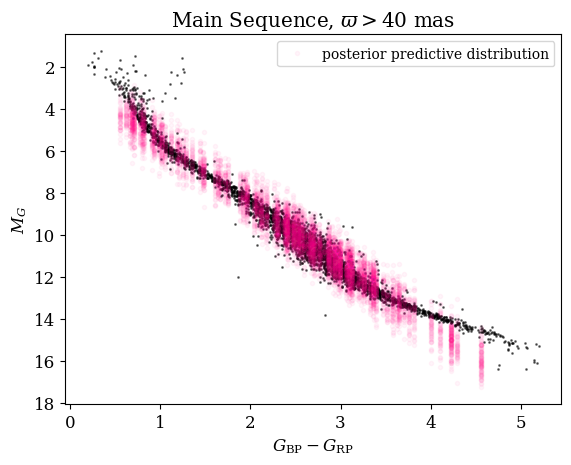

In [39]:
N = 25
label = "posterior predictive distribution"
for i in random.choice(rng_key, len(post_pred_y), (50,)):
    plt.plot(x[::N], post_pred_y[i, ::N], ".", color="deeppink", alpha=0.04, label=label)
    label = None

plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

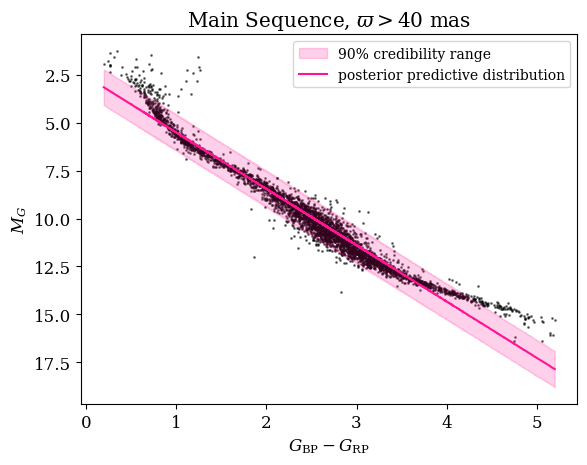

In [40]:
sort_x = jnp.argsort(x)
x_sorted = x[sort_x]
post_pred_y_sorted = post_pred_y[:, sort_x]

y_mean = jnp.mean(post_pred_y_sorted, axis=0)
y_low, y_high = jnp.percentile(post_pred_y_sorted, jnp.array([5, 95]), axis=0)

plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

plt.fill_between(x_sorted, y_low, y_high, color='deeppink', alpha=0.2, label='90% credibility range')
plt.plot(x_sorted, y_mean, color='deeppink', label='posterior predictive distribution')

plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()